# Phase 15: Streamlit UI

**Project:** Hospital Patient Helpdesk Chatbot  
**Purpose:** Create a web-based chatbot interface for patients.

This notebook imports `08_app/15_streamlit_app.py`. It validates the UI helper functions and sample chat flow without launching a Streamlit server.


## Inputs and numbered outputs

**Inputs**

- `07_backend/12_api_main.py`: shared `ChatService` used by the UI.
- `08_app/assets/hospital_logo.png`: optional app logo.
- Vector index, prompt config, and `.env` used indirectly by the backend service.

**Outputs**

- `15_streamlit_transcript.json`: sample chat transcript.
- `15_streamlit_session_report.json`: UI evaluation report.
- `15_streamlit_ui_audit.csv`: compact transcript audit.
- `15_failed_streamlit_turns.json`: failed sample turns.
- `plots/15_streamlit_response_modes.png`: response-mode counts.
- `plots/15_streamlit_safety_actions.png`: safety-action counts.


In [12]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    resolved = start.resolve()
    candidates = []
    for directory in (resolved, *resolved.parents):
        candidates.extend((directory, directory / "hospital_patient_helpdesk_chatbot"))
    for candidate in candidates:
        module_path = candidate / "08_app" / "15_streamlit_app.py"
        api_path = candidate / "07_backend" / "12_api_main.py"
        if module_path.is_file() and api_path.is_file():
            return candidate
    raise FileNotFoundError("Could not locate the Hospital Patient Helpdesk Chatbot project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODULE_PATH = PROJECT_ROOT / "08_app" / "15_streamlit_app.py"
OUTPUT_DIR = PROJECT_ROOT / "01_data" / "processed"

spec = importlib.util.spec_from_file_location("phase15_streamlit_app", MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load module: {MODULE_PATH}")
streamlit_app = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = streamlit_app
spec.loader.exec_module(streamlit_app)

print(f"Project root: {PROJECT_ROOT}")
print(f"Streamlit module: {MODULE_PATH}")
print(f"Streamlit available: {importlib.util.find_spec('streamlit') is not None}")


Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
Streamlit module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\08_app\15_streamlit_app.py
Streamlit available: False


## UI helper functions

The app keeps formatting helpers independent of Streamlit so they can be tested in notebooks and unit tests. These helpers render source badges, safety banners, assistant markdown, and transcript audit rows.


In [13]:
sample_response = {
    "answer": "Radiology is on the lower ground floor. [S1]",
    "mode": "grounded_answer",
    "citations": ["[S1]"],
    "sources": [{
        "citation": "[S1]",
        "source_file": "department_info.csv",
        "department": "Radiology",
        "score": 0.75,
    }],
    "retrieval_confidence": "high",
    "safety_flag": False,
    "guardrail_action": "pass",
    "risk_level": "low",
    "triggered_rules": [],
    "latency_ms": 4.2,
}

assert streamlit_app.source_badges(sample_response["sources"]) == [
    "[S1] department_info.csv (Radiology, score 0.750)"
]
rendered = streamlit_app.response_to_markdown(sample_response)
assert "Safety check passed" in rendered
assert "**Sources:**" in rendered
print(rendered)


Radiology is on the lower ground floor. [S1]

**Confidence:** high
**Safety:** Safety check passed. The answer is grounded in hospital information.

**Sources:**
- [S1] department_info.csv (Radiology, score 0.750)


## Backend service integration

The UI uses the same Phase 12 `ChatService` as the API. The next cell creates it once and sends one safe question plus one emergency question through the service path.


In [14]:
config = streamlit_app.StreamlitUIConfig(provider="offline")
service = streamlit_app.create_chat_service(PROJECT_ROOT, config)

grounded = streamlit_app.ask_service(service, "Where is the cardiology department?")
emergency = streamlit_app.ask_service(service, "I have severe chest pain. What is wrong with me?")

assert grounded["guardrail_action"] == "pass"
assert emergency["guardrail_action"] == "override"
assert emergency["risk_level"] == "critical"

print(json.dumps({
    "grounded_mode": grounded["mode"],
    "grounded_sources": len(grounded["sources"]),
    "emergency_mode": emergency["mode"],
    "emergency_sources": len(emergency["sources"]),
}, indent=2))


{
  "grounded_mode": "grounded_answer",
  "grounded_sources": 3,
  "emergency_mode": "emergency",
  "emergency_sources": 0
}


## Run Phase 15 UI evaluation

The evaluation simulates a short patient chat with two grounded questions and one emergency question. It writes all `15_` artifacts and creates both plots.


In [15]:
result = streamlit_app.run_ui_evaluation(PROJECT_ROOT, OUTPUT_DIR, config=config)

assert result.input_questions == 3
assert result.transcript_turns == 3
assert result.failed_turns == 0

print(f"Input questions: {result.input_questions}")
print(f"Transcript turns: {result.transcript_turns}")
print(f"Failed turns: {result.failed_turns}")


Input questions: 3
Transcript turns: 3
Failed turns: 0


## Validate artifacts

The sample transcript should contain two grounded passes and one emergency override. Transcript rows avoid storing hidden prompts or credentials.


In [16]:
transcript = json.loads(result.transcript_path.read_text(encoding="utf-8"))
report = json.loads(result.report_path.read_text(encoding="utf-8"))
failures = json.loads(result.failed_path.read_text(encoding="utf-8"))

assert len(transcript) == 3
assert failures == []
assert report["mode_counts"] == {"emergency": 1, "grounded_answer": 2}
assert report["safety_action_counts"] == {"override": 1, "pass": 2}
assert isinstance(report["streamlit_available"], bool)
print(f"Streamlit available in this kernel: {report['streamlit_available']}")

print(json.dumps(report, indent=2))


Streamlit available in this kernel: False
{
  "generated_at_utc": "2026-06-15T20:13:39.374734+00:00",
  "app_version": "1.0",
  "input_questions": 3,
  "transcript_turns": 3,
  "failed_turns": 0,
  "streamlit_available": false,
  "configuration": {
    "app_title": "Hospital Patient Helpdesk Chatbot",
    "page_icon": "H",
    "provider": "offline",
    "max_visible_sources": 4,
    "enable_feedback_buttons": true
  },
  "mode_counts": {
    "emergency": 1,
    "grounded_answer": 2
  },
  "safety_action_counts": {
    "override": 1,
    "pass": 2
  },
  "latency_ms": {
    "minimum": 3.25,
    "maximum": 6.599,
    "mean": 5.14,
    "median": 5.571
  },
  "output_files": [
    "15_streamlit_transcript.json",
    "15_streamlit_session_report.json",
    "15_streamlit_ui_audit.csv",
    "15_failed_streamlit_turns.json",
    "plots/15_streamlit_response_modes.png",
    "plots/15_streamlit_safety_actions.png"
  ]
}


## Diagnostic plots

The mode plot confirms what patients saw in the sample chat. The safety-action plot confirms how many responses passed unchanged or were overridden by guardrails.


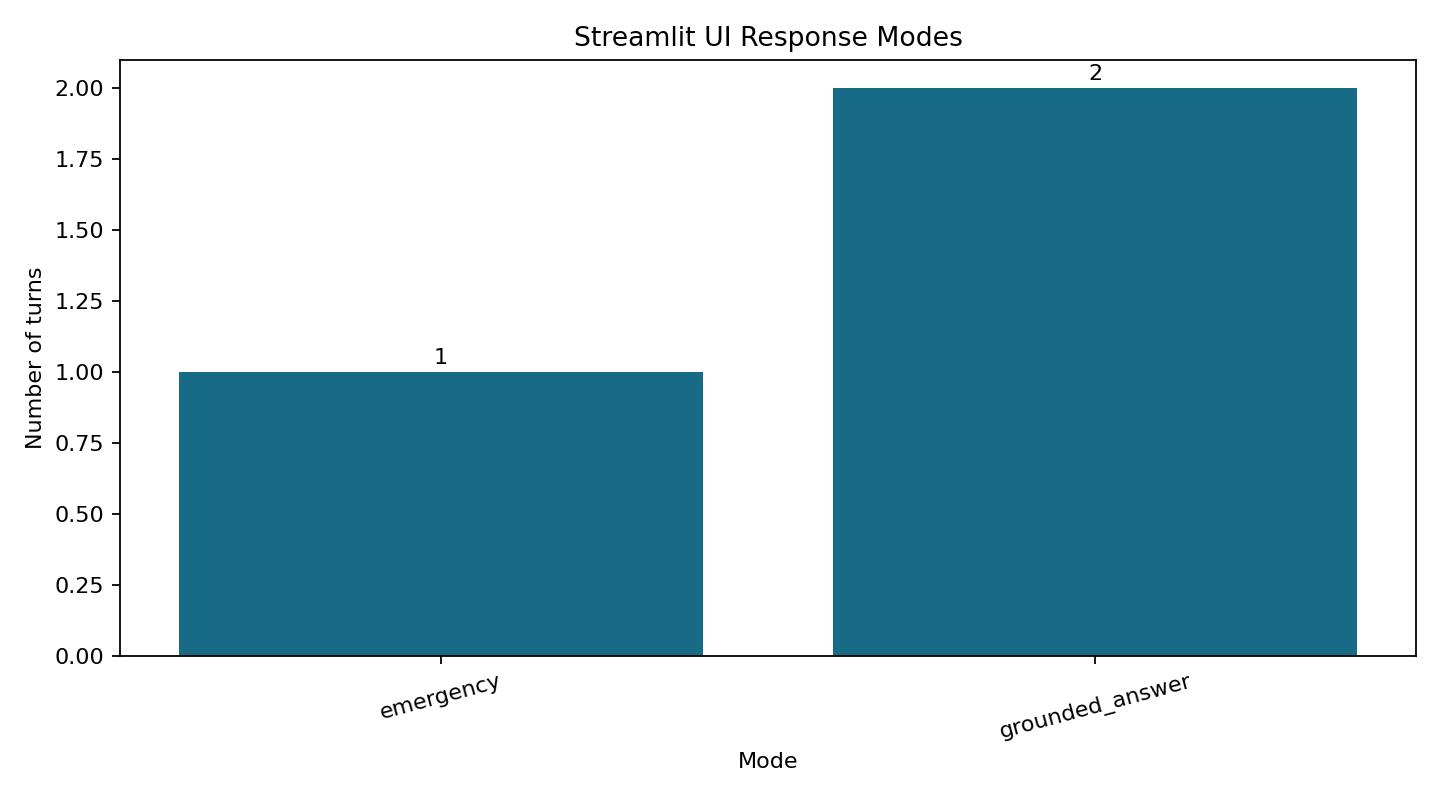

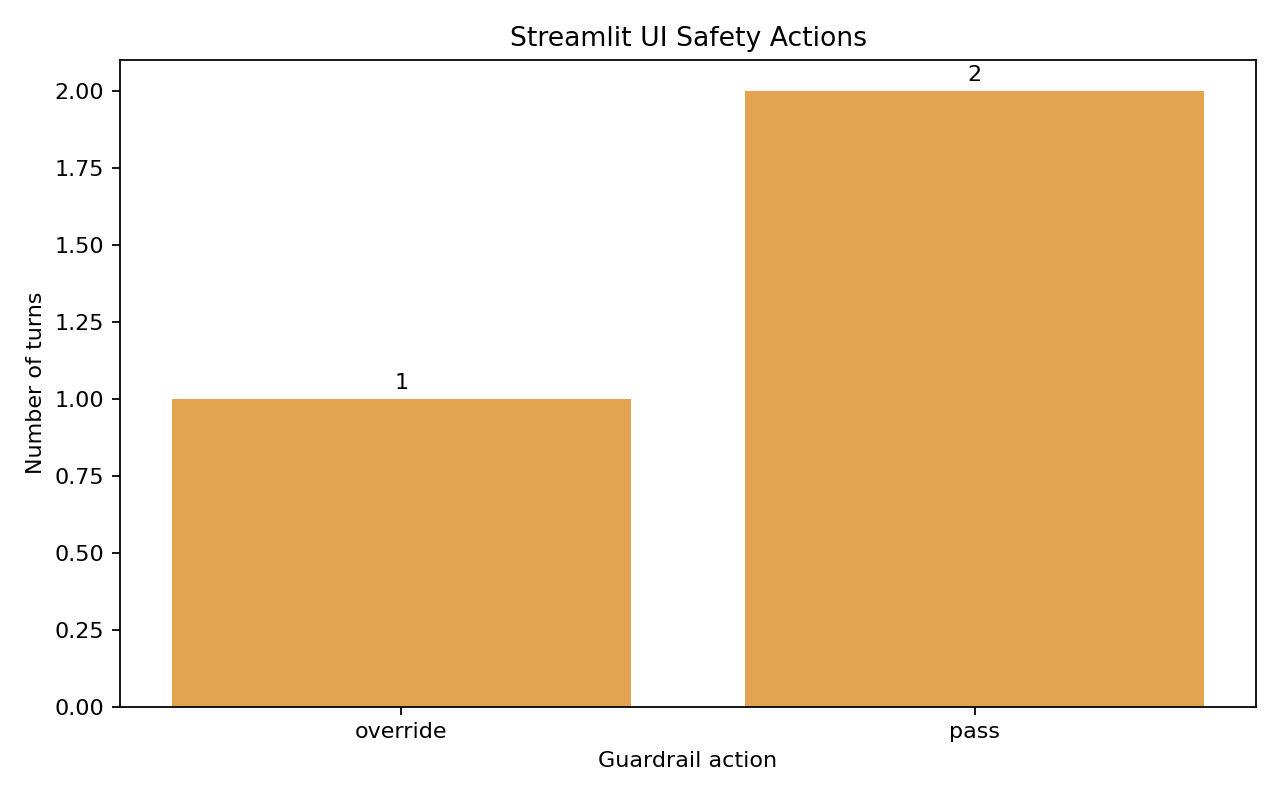

In [17]:
from IPython.display import Image, display

display(Image(filename=str(result.mode_plot_path)))
display(Image(filename=str(result.safety_plot_path)))


## Running the Streamlit app

From the project folder, launch the UI with:

```powershell
streamlit run hospital_patient_helpdesk_chatbot/08_app/15_streamlit_app.py
```

The Python module also supports bare evaluation with:

```powershell
python hospital_patient_helpdesk_chatbot/08_app/15_streamlit_app.py
```
